# Comparing healthy and MS predictions

Brain age predictions are generated for both healthy subjects and MS patients in order to investigate whether the models can differentiate between healthy and disease-related brain patterns.

The analysis includes:
- 32 healthy HCP subjects (22–35 years)
- 32 MS patients from the OFAMS dataset within a similar age range

Two different brain age models are compared:
1. A model trained on unsmoothed asymmetry maps
2. A model trained on smoothed asymmetry maps

In [1]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Define the folder containing prediction files
pred_env = Path("/Users/anneaasengen/MS_project/healthy_predictions")

# File containing predictions from the model trained on unsmoothed asymmetry maps
unsmooth_predictions = pred_env / "comparing_predictions.csv"

# File containing predictions from the model trained on smoothed asymmetry maps
smooth_predictions = pred_env / "smoothing_comparing_predictions.csv"

In [3]:
# Load prediction data from both models into pandas DataFrames
# Each DataFrame contains predicted brain age values for healthy subjects and MS patients
df_unsmooth = pd.read_csv(unsmooth_predictions) # predictions from unsmoothed model
df_smooth = pd.read_csv(smooth_predictions) # predictions from smooothed model

In [4]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,dataset,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,OFAMS,33.492504,-1.507496,33.919716,-1.080284
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,OFAMS,40.867573,16.867573,41.207672,17.207672
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1105,F,31.0,OFAMS,46.275234,15.275234,46.551460,15.551460
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1107,F,28.0,OFAMS,46.545105,18.545105,46.818146,18.818146
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1202,F,33.0,OFAMS,34.356297,1.356297,34.773304,1.773304


In [5]:
df_smooth.head()

,image_path,participant_id,sex,age_BL,dataset,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,OFAMS,32.195694,-2.804306,32.905727,-2.094273
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,OFAMS,36.474022,12.474022,37.120200,13.120201
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1105,F,31.0,OFAMS,42.306854,11.306854,42.865974,11.865974
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1107,F,28.0,OFAMS,34.397000,6.396999,35.074177,7.074177
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1202,F,33.0,OFAMS,26.879265,-6.120735,27.668652,-5.331348


## Plot: Predicted vs cronological age (raw predictions)

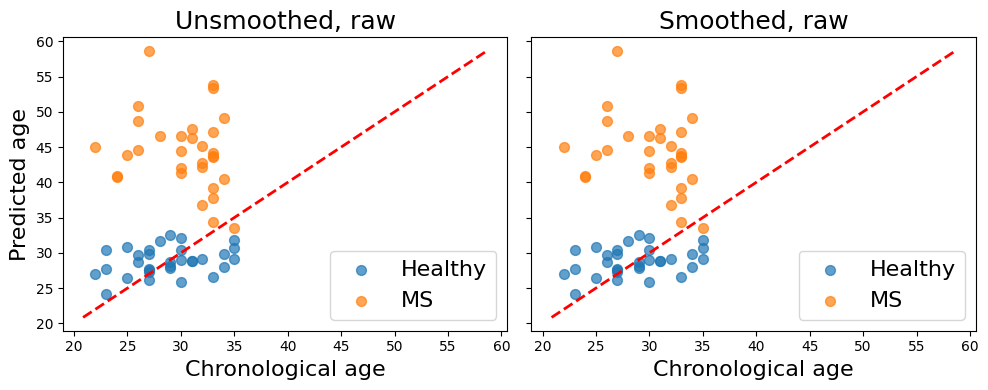

In [6]:
# Font sizes used throughout the figure
# These are defined separately to ensure consistent formatting
title_fs = 18
legend_fs = 16
tick_fs = 10
axislabel_fs = 16

# Column names used in the prediction files
age_col = "age_BL"                # chronological age
pred_col = "predicted_age"       # raw predicted brain age
pred_bc_col = "predicted_age_bc" # bias-corrected predicted brain age


# Determine common axis limits for both subplots
# This ensures direct visual comparison between the two models
mn_raw = min(
    df_unsmooth[age_col].min(),
    df_unsmooth[pred_col].min(),
    df_smooth[age_col].min(),
    df_smooth[pred_col].min()
)


mx_raw = max(
    df_unsmooth[age_col].max(),
    df_unsmooth[pred_col].max(),
    df_smooth[age_col].max(),
    df_smooth[pred_col].max()
)

# Create a figure with two side-by-side subplots
# Both plots share the same x- and y-axis ranges
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)


# Unsmoothed, raw
ax = axes[0]
label_map = {
    "HCP": "Healthy",
    "OFAMS": "MS"
}
# Rename dataset labels 
for grp in ["HCP", "OFAMS"]:

    # Select rows belonging to the current group
    sub = df_unsmooth[df_unsmooth["dataset"] == grp]

    # Scatter plot of chronological age vs predicted age
    ax.scatter(sub[age_col], sub[pred_col],
               label=label_map[grp], alpha=0.7, s=50)



# Add identity line (perfect predictions)
# Points above the line indicate overestimation,
# while points below indicate underestimation
ax.plot([mn_raw, mx_raw], [mn_raw, mx_raw], 'r--', linewidth=2)

# Formatting
ax.set_title("Unsmoothed, raw", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Predicted age", fontsize=axislabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)


# Smoothed, raw 
ax = axes[1]
label_map = {
    "HCP": "Healthy",
    "OFAMS": "MS"
}

# Plot healthy subjects and MS patients for the smoothed model
for grp in ["HCP", "OFAMS"]:
    sub = df_unsmooth[df_unsmooth["dataset"] == grp]
    ax.scatter(sub[age_col], sub[pred_col],
               label=label_map[grp], alpha=0.7, s=50)

# Add identity line for reference
ax.plot([mn_raw, mx_raw], [mn_raw, mx_raw], 'r--', linewidth=2)

# Formatting
ax.set_title("Smoothed, raw", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

# Adjust spacing between subplots
plt.tight_layout()
#plt.savefig("ms_vs_hcp_raw_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show() # Display the figure

## Plot: Predicted vs cronological age (bias-corrected predictions)

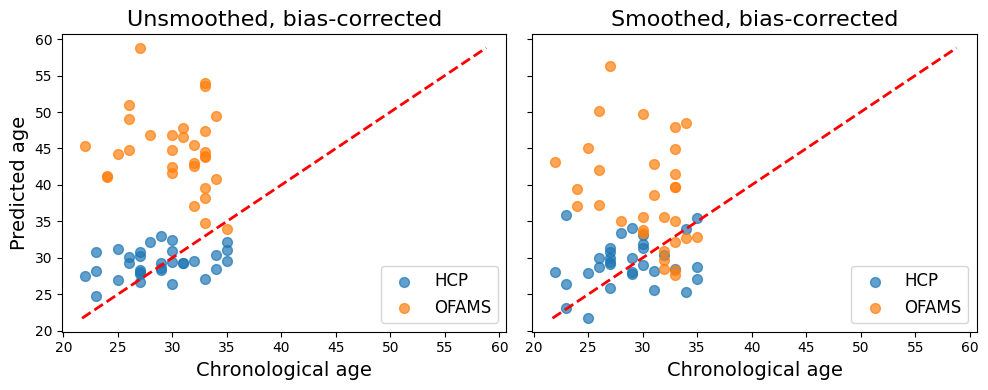

In [7]:
# Determine common axis limits for the bias-corrected predictions
# Using the same axis limits improves comparison between the two models
mn_bc = min(
    df_unsmooth[age_col].min(),
    df_unsmooth[pred_bc_col].min(),
    df_smooth[age_col].min(),
    df_smooth[pred_bc_col].min()
)

mx_bc = max(
    df_unsmooth[age_col].max(),
    df_unsmooth[pred_bc_col].max(),
    df_smooth[age_col].max(),
    df_smooth[pred_bc_col].max()
)

# Create side-by-side subplots for the bias-corrected predictions
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)


# Unsmoothed, bias-corrected 
ax = axes[0]

# Plot healthy subjects and MS patients separately
for grp in ["HCP", "OFAMS"]:
    sub = df_unsmooth[df_unsmooth["dataset"] == grp]
    ax.scatter(sub[age_col], sub[pred_bc_col], label=grp, alpha=0.7, s=50)

# Add identity line representing perfect agreement
# between chronological age and predicted age
ax.plot([mn_bc, mx_bc], [mn_bc, mx_bc], 'r--', linewidth=2)

# Formatting
ax.set_title("Unsmoothed, bias-corrected", fontsize=16)
ax.set_xlabel("Chronological age", fontsize=14)
ax.set_ylabel("Predicted age", fontsize=14)
ax.legend(fontsize=12)


# Smoothed, bias-corrected 
ax = axes[1]

# Plot healthy subjects and MS patients separately
for grp in ["HCP", "OFAMS"]:
    sub = df_smooth[df_smooth["dataset"] == grp]
    ax.scatter(sub[age_col], sub[pred_bc_col], label=grp, alpha=0.7, s=50)

# Add identity line
ax.plot([mn_bc, mx_bc], [mn_bc, mx_bc], 'r--', linewidth=2)

# Formatting
ax.set_title("Smoothed, bias-corrected", fontsize=16)
ax.set_xlabel("Chronological age", fontsize=14)
ax.legend(fontsize=12)

# Improve spacing between subplots
plt.tight_layout()
#plt.savefig("ms_vs_hcp_bias_corrected_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show() # Display figure